In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Total Features:", X.shape[1])
print("Target Classes:", data.target_names)

Dataset Shape: (569, 30)
Total Features: 30
Target Classes: ['malignant' 'benign']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [5]:
start_time = time.time()

model = SVC(kernel="linear")

model.fit(X_train_scaled, y_train)

print("SVM Model Training Completed")

SVM Model Training Completed


In [6]:
y_pred = model.predict(X_test_scaled)

end_time = time.time()

execution_time = end_time - start_time

print("Predictions Completed")
print("Execution Time:", execution_time, "seconds")

Predictions Completed
Execution Time: 14.039987325668335 seconds


In [7]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, y_pred, pos_label=0
)

recall = recall_score(
    y_test, y_pred, pos_label=0
)

f1 = f1_score(
    y_test, y_pred, pos_label=0
)

print("FULL FEATURES RESULTS")

print("Number of Features:", X.shape[1])
print("Accuracy:", accuracy * 100, "%")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Execution Time:", execution_time, "seconds")

FULL FEATURES RESULTS
Number of Features: 30
Accuracy: 97.36842105263158 %
Precision: 0.9534883720930233
Recall: 0.9761904761904762
F1 Score: 0.9647058823529412
Execution Time: 14.039987325668335 seconds


In [8]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



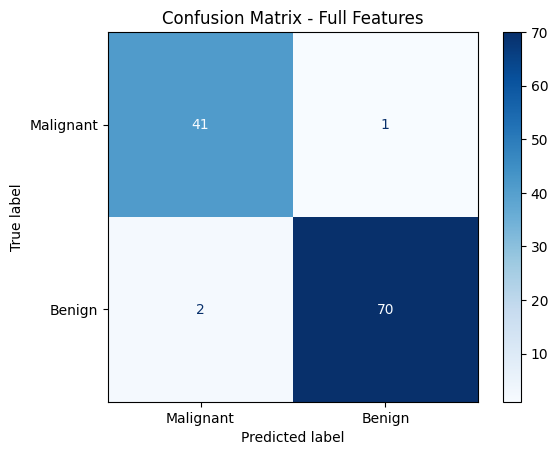

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Full Features")

plt.show()

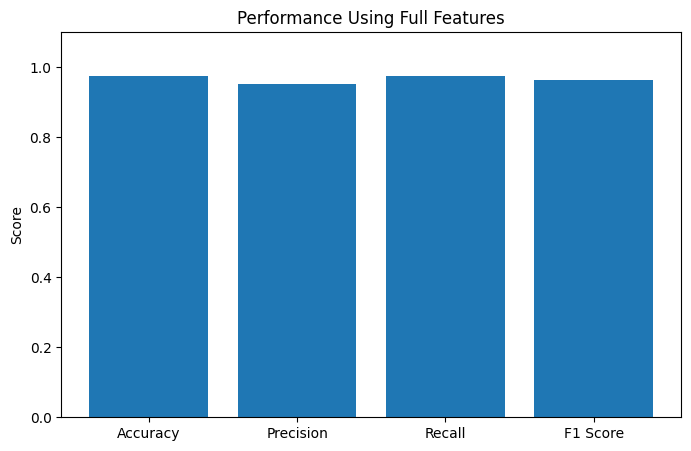

In [10]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(8, 5))

plt.bar(metrics.keys(), metrics.values())

plt.title("Performance Using Full Features")

plt.ylabel("Score")

plt.ylim(0, 1.1)

plt.show()